# Tutorial 2: Analyzing G-Tensors

This tutorial demonstrates how to use the python API to manipulate, analyze, and plot G-Tensor data.

## Prerequisites

Before starting this tutorial, ensure you have:
- MuTopia package installed
- Download the pre-compiled data to the `tutorial_data` directory

## 1. The elements of a G-Tensor

In [1]:
import mutopia.analysis as mu
import mutopia.plot.track_plot as tr
import numpy as np

In [2]:
data=mu.gt.load_dataset("tutorial_data/Liver.nc", with_samples=False)
data

You can see the G-Tensor comprises many hierarchical sections with data spanning multiple dimensions. The `Dimensions` listed at the top indicate the multiple dimensions that may be referenced by the data. In this instance, the G-Tensor contains dimensions for:
* locus - regions across the genome
* context - the trinucleotide context at which a mutation is found
* configuration - configuration indicates whether a mutation was found at a C/T base or an A/G base. Typically, mutational signatures are oriented relative to the C/T base, but we track both orientations to account for stranded features.
* sample - the number of samples included in the dataset

You can click on the various "sections" to view their contents. To access variables in a certain section, like "length" under the "Regions" section, you can use:

In [3]:
data.sections["Regions"]["length"]

<xarray.DataArray 'length' (locus: 388247)> Size: 2MB
array([ 3141., 10725.,  4845., ...,  6438.,  3450.,  3408.], dtype=float32)
Coordinates:
  * locus    (locus) int64 3MB 0 1 2 3 4 ... 388242 388243 388244 388245 388246

Or:

In [4]:
data["Regions/length"]

<xarray.DataArray 'Regions/length' (locus: 388247)> Size: 2MB
array([ 3141., 10725.,  4845., ...,  6438.,  3450.,  3408.], dtype=float32)
Coordinates:
  * locus    (locus) int64 3MB 0 1 2 3 4 ... 388242 388243 388244 388245 388246

In fact the hierarchy is a trick of the UI here. A G-Tensor in fact is simply an X-array dataset where we've added a little functionality for variables saved with filepath-like names!
I suggest reading a little bit about X-array to understand some of the semantics with dealing in X-array datasets.

Besides the `Regions` section, which describes the genomic loci, we also have the `Features` section, which contains our genomic state features, sectioned by cell type (side note: whenever a variable does not belong to a section, it just goes under "Data" - you do not need to prefix with "Data" to access these.)

In [5]:
data.sections["Features"]

<xarray.Dataset> Size: 35MB
Dimensions:            (locus: 388247)
Coordinates:
  * locus              (locus) int64 3MB 0 1 2 3 ... 388243 388244 388245 388246
Data variables: (12/19)
    GeneExpression     (locus) float32 2MB nan nan nan nan ... nan nan nan nan
    GeneStrand         (locus) int8 388kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    GenePosition       (locus) float32 2MB nan nan nan nan ... nan nan nan nan
    ReplicationStrand  (locus) int8 388kB 0 0 0 1 1 1 1 1 1 ... -1 0 0 0 0 0 0 0
    RepliseqS4         (locus) float32 2MB 7.007 2.3 2.088 ... 5.1 5.495 5.105
    NucleotideRatio    (locus) float32 2MB 0.3104 0.2271 0.1438 ... 0.239 0.239
    ...                 ...
    H3K4me3            (locus) float32 2MB 0.2934 5.248 0.3616 ... 0.1928 0.1672
    RepliseqG1b        (locus) float32 2MB 45.48 52.38 52.3 ... 18.0 16.9 17.2
    RepliseqS2         (locus) float32 2MB 6.4 6.0 6.1 6.1 ... 29.4 29.7 31.5
    RepliseqS1         (locus) float32 2MB 24.92 27.42 27.89 ... 18.4 19.49 21.0
    H3K27ac            (locus) float32 2MB 0.9603 7.082 ... 0.07612 0.05248
    H3K27me3           (locus) float32 2MB 0.0852 0.0844 ... 0.2999 0.1846
Attributes:
    name:            liver_simple
    dtype:           sbs
    genome_file:     /n/data1/hms/dbmi/park/ctDNA_loci_project/locusregressio...
    fasta_file:      /n/data1/hms/dbmi/park/SOFTWARE/REFERENCE/hg38/cgap_matc...
    blacklist_file:  /n/data1/hms/dbmi/park/ctDNA_loci_project/locusregressio...
    region_size:     10000
    filename:        tutorial_data/Liver.nc
    regions_file:    Liver.nc.regions.bed

The methods under `mu.gt` are operations which operate on G-Tensors. `annot_empirical_marginal` calculates the average counts for each locus and context across your dataset:

In [6]:
data = mu.gt.annot_empirical_marginal(data)
data

Reducing samples: 100%|██████████| 184/184 [00:27<00:00,  6.70it/s]
INFO: Mutopia:Added key: "empirical_marginal"
INFO: Mutopia:Added key: "empirical_marginal_locus"


You can see it added keys for `empirical_marginal`, which has dimensions (context, locus), but also `empirical_marginal_locus`, which simply sums over the "context" dimension. This is a common pattern in MuTopia methods, giving you access to multiple levels of summarized data.

Another important accessor is `mu.gt.fetch_features`, which returns a matrix of features which match some query (wildcards with `*` may be provided):

In [7]:
mu.gt.fetch_features(data, "Gene*").to_pandas().T.head(3)

feature,GeneExpression,GeneStrand,GenePosition
locus,,,
0,NaN,0.0,NaN
1,NaN,0.0,NaN
2,NaN,0.0,NaN


## 2. Manipulating G-Tensors

Since G-Tensors are really just souped-up X-arrays, we can do all sorts of fancy manipulations with the data. Mutopia provides a few additional operations like `mu.gt.slice_regions` and `mu.gt.slice_samples`. 

Of particular note is the ability to sum across dimensions. To view the overall length distribution of the data, for example, we can do:

<Axes: >

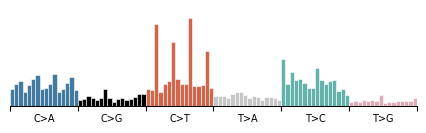

In [8]:
data.modality().plot(
    data["empirical_marginal"].sum(dim=("locus", "configuration"))
)

One of the unique features of G-Tensors is the ability to load sample data from disk. You can check out the samples your dataset contains with:

In [9]:
data.list_samples()[:5]

array(['0040b1b6-b07a-4b6e-90ef-133523eaf412',
       '00c27940-c623-11e3-bf01-24c6515278c0',
       '03c88506-d72e-4a44-a34e-a7f0564f1799',
       '0831e45e-c623-11e3-bf01-24c6515278c0',
       '0a9c9db0-c623-11e3-bf01-24c6515278c0'], dtype='<U36')

And load the sample data like so:

In [10]:
data.fetch_sample("0040b1b6-b07a-4b6e-90ef-133523eaf412")

Format,gcxs
Data Type,float32
Shape,"(2, 96, 388247)"
nnz,13687
Density,0.00018361109894817818
Read-only,True
Size,1.6M
Storage ratio,0.01
Compressed Axes,"(2,)"
Format,coo
Data Type,float64


A sample contains two data elements: the `X` matrix - the counts of each observed fragment for each fragment length bin at each locus, and `ploidy` - the copy number at each locus, but transformed such that: `p = CN/2 - 1`, which allows us to save the data in a sparse manner (since a diploid region corresponds with p=0). 

The ability to load data persists through slicing the data:

In [11]:
(
    mu.gt.slice_regions(data, "chr1:41007569-54616441")
    .fetch_sample("0040b1b6-b07a-4b6e-90ef-133523eaf412")
    .dims
)

INFO: Mutopia:Found 2343/388247 regions matching query.


FrozenMappingWarningOnValuesAccess({'configuration': 2, 'context': 96, 'locus': 2343})

## 3. Plotting G-Tensor data

Plotting G-Tensors works by composing `views` - sections of the genome, and `configs` - the configuration of the tracks you want to plot. Configurations themselves are functions of `views`, and are data-independent descriptions of the plot you want to make.

The general form of a `view` is a list, tuple, or other iterable of plot elements, like `tr.scale_bar`, `tr.scatterplot`, `tr.heatmap_plot`, etc. Each of these plots are ultimately wrappers around the corresponding `matplotlib` plot, so you can pass the familiar keyword argument to configure plot aesthetics.

Unlike `matplotlib` or `seaborn`, however, you do not directly provide any data to a `tr.{plot}` element. Instead, the first argument describes *how* to access that data from a G-Tensor object. For this, you can use the methods:
1. `tr.select` - select this variable (or variables) from the G-Tensor.
2. `tr.feature_matrix` - select the genomic features which match the query string.

Sometimes, you want to plot a transformation of some stored variable. This is simple with `tr.pipeline`. You simply provide the series of functions you wish to run on the underlying data. For example, to first select some data, then apply the sqrt transformation, one would provide:
```
tr.pipeline(
    tr.select(variable),
    lambda x : np.sqrt(x)
)
```

We provide a few ready-to-go transformations, like and `tr.renorm`, `tr.clip`. The `tr.apply_rows` function applies any provided transformation to each row of a matrix independently. This style of composing configurations enables the construction complex multimodal genome plots. Let's build one!

(**Note:** you can specify additional arguments for a config that must be filled at run-time).

The following example has a little bit of everything:

In [12]:
plot_config = lambda view, scalebar_bp : ( #supply scalebar_bp at runtime
    tr.scale_bar(scalebar_bp, scale="mb" if scalebar_bp >= 1_000_000 else "kb"),
    tr.ideogram("tutorial_data/cytoBand.txt"),
    tr.stack_plots( # this context overlays whichever plots are provided
        tr.scatterplot(
            tr.pipeline(
                tr.select("empirical_marginal_locus"),
                view.smooth(5),
            ),
            s=0.5,
            alpha=0.5,
            color="grey",
            label="Observed"
        ),
        tr.line_plot(
            tr.pipeline(
                tr.select("empirical_marginal_locus"),
                view.smooth(20),
            ),
            label="Smoothed",
            linewidth=0.5,
            color=mu.pl.categorical_palette[0], # nice colors
        ),
        height=1.5,
        label="(log) Inverse\nfragmentation rate"
    ),
    tr.spacer(0.2),
    tr.fill_plot(
        tr.select("Features/H3K27me3"),
        color=mu.pl.categorical_palette[1],
        alpha=0.8,
        height=0.75,
    ),
    tr.fill_plot(
        tr.select("Features/H3K27ac"),
        color=mu.pl.categorical_palette[1],
        alpha=0.8,
        height=0.75,
    )
)

Now, to use the configuration, make a "view" of the data using `make_view`, supplying the data a region of interest:

In [13]:
view = tr.make_view(data, "chr1:41007569-54616441")

INFO: Mutopia:Found 2343/388247 regions matching query.


Finally, use `tr.plot_view` to render the configuration - make sure to supply any required runtime arguments!

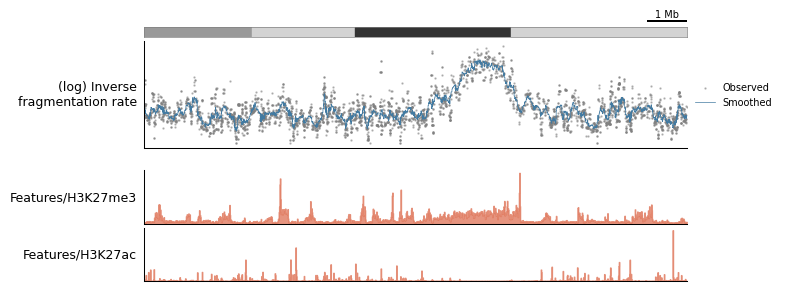

In [14]:
tr.plot_view(plot_config, view, scalebar_bp=1_000_000)
None

To demonstrate the extensibility of a plotting configuration, let's say you found an interesting locus and you want to "zoom in". You can simply re-use the same configuration, modify the run-time paramters, and provide a view of a different region of the genome:

INFO: Mutopia:Found 403/388247 regions matching query.


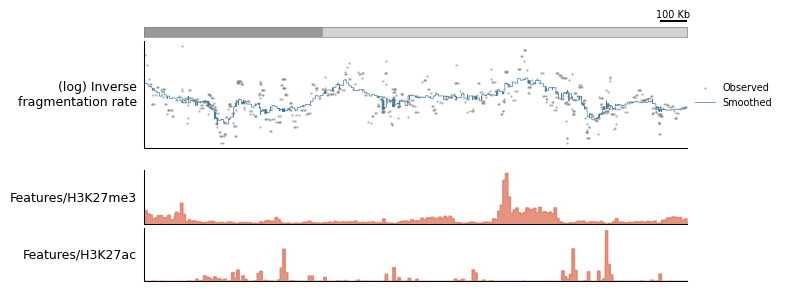

In [15]:
zoomed_view = tr.make_view(data, "chr1:43007569-45116441")
tr.plot_view(plot_config, zoomed_view, scalebar_bp=100_000)
None

Plotting only becomes more important once you've trained models on the data - so more on this later!